### ReadMe
This notebook is written for processing the WF dataset
Author: Ruixiang Wu

In [29]:
from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import sys
from PIL import Image, ImageDraw, ImageFont
from tifffile import imwrite
import pathlib

In [39]:
parent_dir = '/Users/yatangli/Library/CloudStorage/Dropbox/Research/codes/WF_GoNogo/'
# current_dir = os.getcwd()
# parent_dir = os.path.dirname(current_dir)
os.chdir(parent_dir)
if parent_dir not in sys.path: 
    sys.path.append(parent_dir)
from utils.wf_utils import *

### Read and process WF imaging data

In [41]:
base_dir = "/Volumes/Data_attention/Transfer learning/LinShu/DATA_linshu/000 Widefield"
mouse_id = "A095"
session = "20250903"
# config_path = "/home/lsh/WF_GoNogo/config/A095_config.yaml"
rawPath = os.path.join(base_dir, mouse_id, session)
if not os.path.exists(rawPath):
    print(f"The specified path does not exist: {rawPath}")

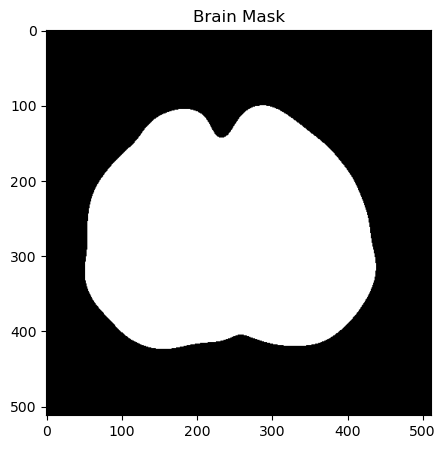

In [43]:
# mask save in ./rawPath/QualityControl/brain_mask.npy
mask_path = os.path.join(rawPath, "QualityControl/brain_mask.npy")
if not os.path.exists(mask_path):
    print(f"The specified mask path does not exist: {mask_path}")

mask = np.load(mask_path)
# print(f"Mask shape: {mask.shape}")
show_one_image(mask, title="Brain Mask")

The number of 470 images: 29927
The number of 405 images: 29928


100%|█████████████████████████████████████| 29927/29927 [33:21<00:00, 14.95it/s]


The shape of the processed images: (29927, 2, 512, 512)


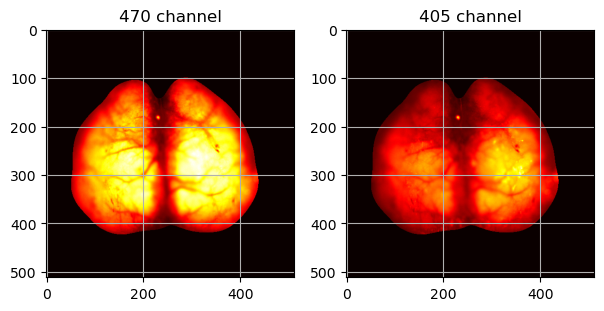

In [45]:
# n_preview = 300 # set to None to process all images, 
# or set to an integer to limit the number of images processed for preview

# if mask is not None, apply the mask to the images
stack, files_470 = images2tiff_two_channel(rawPath,
    mask=mask)
print("The shape of the processed images:", stack.shape)

# visualize the first image of each channel
images = list(stack[0])
show_images(images, titles=['470 channel', '405 channel'])

(29927, 2)
(2,)
detect_lum_outlier: No dim outliers frames detected!


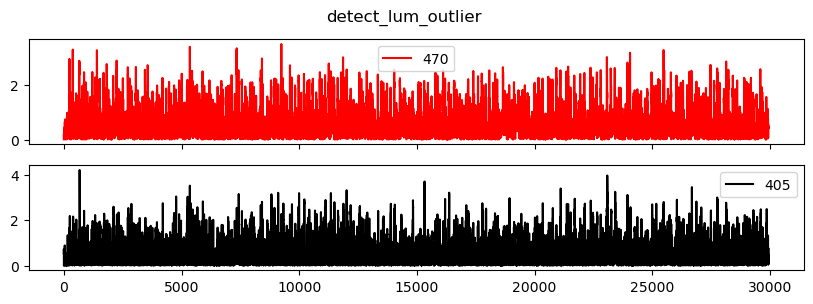

In [46]:
stack_mean = np.mean(stack, axis=(2, 3))
# print("The shape of the stack_mean:", stack_mean.shape)
outlier_index_470, outlier_index_405 = detect_lum_outlier(stack_mean, 
    threshold=6, plot=True)

stack_corrected = correct_lum_outlier(stack, outlier_index_470,
    outlier_index_405, plot=False)

In [ ]:
# calculate delta_f/f for 470 channel
# the 'delta_ff_3d' is time consuming, optimize 'cal_base' may help
stack_470_dff = delta_ff_3d(stack_corrected[:, 0, :, :], win=150)
# print("The shape of stack_470_dff:", stack_470_dff.shape)

stack_405_dff = delta_ff_3d(stack_corrected[:, 1, :, :], win=150)
# print("The shape of stack_405_dff:", stack_405_dff.shape)

dff = stack_470_dff - stack_405_dff
# Scale the dff to range of 16 bit
dff_min = dff.min()
dff_max = dff.max()
dff = 65535 * (dff - dff_min) / (dff_max - dff_min)

100%|█████████████████████████████████████████| 512/512 [23:27<00:00,  2.75s/it]


In [ ]:
dff_text = np.copy(dff)
for trial,i in enumerate(wf_trial_0_idx):
    if i <dff_text.shape[0]:
        dff_text[i,:,:] = add_text_to_image(dff[i,:,:], trial+1, status="on")
for trial,i in enumerate(wf_trial_1_idx):
    if i <dff_text.shape[0]:
        dff_text[i,:,:] = add_text_to_image(dff[i,:,:], trial+1, status="off")
# save the dff_scaled as tiff file

save_path = os.path.join(rawPath, f'{mouse_id}_{session}_dff.tif')
imwrite(save_path, dff_text.astype(np.uint16), imagej=True)
print('The dff tiff file saved to:', save_path)

### Load time information and lign imaging data to trials

In [ ]:
timePath = os.path.join(rawPath, 'time')
trial_path = os.path.join(timePath, 'trial_timestamp.npy')
trial_timestamp = np.load(trial_path)
stim_path = os.path.join(timePath, 'stim_timestamp.npy')
stim_timestamp = np.load(stim_path)
wf_path = os.path.join(timePath, 'widefield_timestamps_blue.npy')
wf_timestamp = np.load(wf_path)
wf_timestamp = wf_timestamp/1e3
print(wf_timestamp.shape)
plt.plot(trial_timestamp,'.')
plt.show()
plt.plot(stim_timestamp,'r.')
plt.show()
plt.plot(wf_timestamp,'.')
plt.show()

In [ ]:
wf_trial_0_idx = find_closest_indices(wf_timestamp, trial_timestamp[:,0])
wf_trial_1_idx = find_closest_indices(wf_timestamp, trial_timestamp[:,1])
wf_sf = 10 #Hz
trial_duration = (wf_trial_1_idx-wf_trial_0_idx)/wf_sf
_idx = np.logical_or(trial_duration==5.2,trial_duration==9.7)
wf_trial_1_idx[_idx] = wf_trial_1_idx[_idx]+1
plt.plot((wf_trial_1_idx-wf_trial_0_idx)/wf_sf,'.')
# acutal trial duration is 5.25 s or  9.75 s


In [ ]:
# same averaged images: across all, Hit, CR, FA, Miss trials
trial_type_path = os.path.join(timePath, 'trial_type.npy')
if not os.path.exists(trial_type_path):
    trial_type = load_trial_type(rawPath, timePath)
else:    
    trial_type = np.load(trial_type_path)
plt.plot(trial_type,'.')

In [ ]:
dff_mean_all = compute_trial_mean(dff,wf_trial_0_idx[:10],wf_trial_1_idx[:10])
save_path = os.path.join(rawPath, f'{mouse_id}_{session}_dff_mean_all.tif')
imwrite(save_path, dff_mean.astype(np.uint16), imagej=True)
print('The dff tiff file saved to:', save_path)
type_list = ['Hit','Miss', 'FA','CR']
for i in range(1,5):
    dff_mean_hit = compute_trial_mean(dff,wf_trial_0_idx[trial_type==i],wf_trial_1_idx[:10])
    save_path = os.path.join(rawPath, f'{mouse_id}_{session}_dff_mean_{type_list[i]}.tif')
    imwrite(save_path, dff_mean.astype(np.uint16), imagej=True)
    print('The dff tiff file saved to:', save_path)

In [407]:
type_list = ['Hit','Miss', 'FA','CR']
i = 2
f'{mouse_id}_{session}_dff_mean_{type_list[i]}.tif'

'A095_20250903_dff_mean_FA.tif'

In [376]:
dff[965:1000] 

array([], shape=(0, 512, 512), dtype=float64)

In [291]:
stack.max()

37740

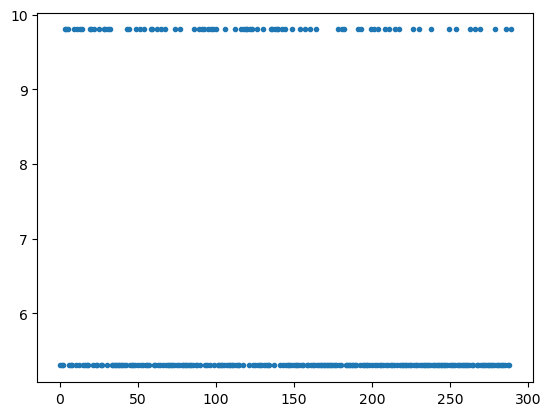

In [276]:
wf_trial_0_idx = find_closest_indices(wf_timestamp, trial_timestamp[:,0])
wf_trial_1_idx = find_closest_indices(wf_timestamp, trial_timestamp[:,1])
wf_sf = 10 #Hz
trial_duration = (wf_trial_1_idx-wf_trial_0_idx)/wf_sf
_idx = np.logical_or(trial_duration==5.2,trial_duration==9.7)
wf_trial_1_idx[_idx] = wf_trial_1_idx[_idx]+1
plt.plot((wf_trial_1_idx-wf_trial_0_idx)/wf_sf,'.')
# acutal trial duration is 5.25 s or  9.75 s


In [342]:
dff_text = np.copy(dff)
for trial,i in enumerate(wf_trial_0_idx):
    if i <dff_text.shape[0]:
        dff_text[i,:,:] = add_text_to_image(dff[i,:,:], trial+1, status="on")
for trial,i in enumerate(wf_trial_1_idx):
    if i <dff_text.shape[0]:
        dff_text[i,:,:] = add_text_to_image(dff[i,:,:], trial+1, status="off")
# save the dff_scaled as tiff file

save_path = os.path.join(rawPath, f'{mouse_id}_{session}_dff.tif')
imwrite(save_path, dff_text.astype(np.uint16), imagej=True)
print('The dff tiff file saved to:', save_path)

The dff tiff file saved to: /Volumes/Data_attention/Transfer learning/LinShu/DATA_linshu/000 Widefield/A095/20250903/A095_20250903_dff.tif


In [338]:
trial_type = load_trial_type(rawPath, timePath)


343

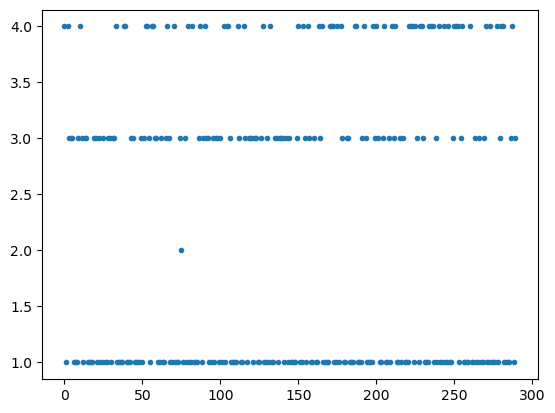

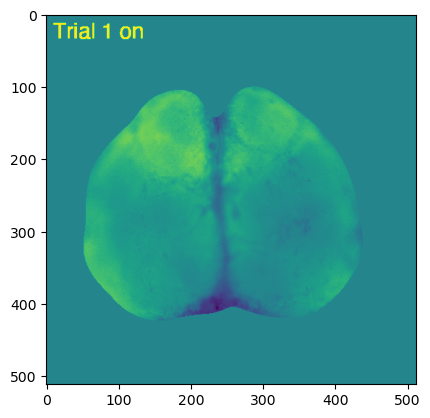

In [326]:
def add_text_to_image(image_array, trial_num, status="on"):
    """
    Add text without affecting other bright pixels.
    
    Parameters:
    image_array: (512, 512) uint16 array
    trial_num: int in [1, 500]
    status: "on" or "off"
    
    Returns:
    (512, 512) uint16 array with clean text overlay
    """
     # Validate
    if not 1 <= trial_num <= 500:
        raise ValueError("trial_num must be between 1 and 500")
    if status not in ["on", "off"]:
        raise ValueError("status must be 'on' or 'off'")
    
    text = f"Trial {trial_num} {status}"
    result = image_array.copy()
    
    # Create a transparent image for text
    text_image = Image.new('RGBA', (512, 512), (0, 0, 0, 0))
    draw = ImageDraw.Draw(text_image)
    
    # Try to load font
    # Try to load a nice font
    font_size = 30
    try:
        # Try common font paths
        font_paths = [
            "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
            "/System/Library/Fonts/Helvetica.ttc",
            "C:/Windows/Fonts/arial.ttf",
            "arial.ttf"
        ]
        
        font = None
        for path in font_paths:
            if os.path.exists(path):
                try:
                    font = ImageFont.truetype(path, font_size)
                    break
                except:
                    continue
        
        if font is None:
            font = ImageFont.load_default()
    except:
        font = ImageFont.load_default()
    
    # Draw text in white with full opacity
    position = (10, 10)
    draw.text(position, text, fill=(255, 255, 255, 255), font=font)
    
    # Convert to numpy array
    text_array = np.array(text_image)
    
    # Extract alpha channel (where text is)
    alpha_channel = text_array[:, :, 3]  # Alpha is the 4th channel
    
    # Create mask where alpha > 0 (text pixels)
    text_mask = alpha_channel > 0
    
    # Apply text to original image
    result[text_mask] = 65535
    
    return result
dff_test = add_text_to_image(dff[1,:,:], 1, status="on")
plt.imshow(dff_test)

In [287]:
save_path = os.path.join(rawPath, f'{mouse_id}_{session}_dff.tif')
imwrite(save_path, dff.astype(np.uint16), imagej=True)

The number of 470 images: 23641
The number of 405 images: 23640


100%|██████████| 1000/1000 [00:06<00:00, 151.57it/s]


(1000, 2)
(2,)
detect_lum_outlier: There are dim outliers frames detected!
Calculating delta F/F of 470 channel...


100%|██████████| 512/512 [00:49<00:00, 10.40it/s]


Calculating delta F/F of 405 channel...


100%|██████████| 512/512 [00:49<00:00, 10.24it/s]


The dff tiff file saved to: /home/wrx/Data_attention/Transfer learning/LinShu/DATA_linshu/000 Widefield/A095/20250905/dff.tif


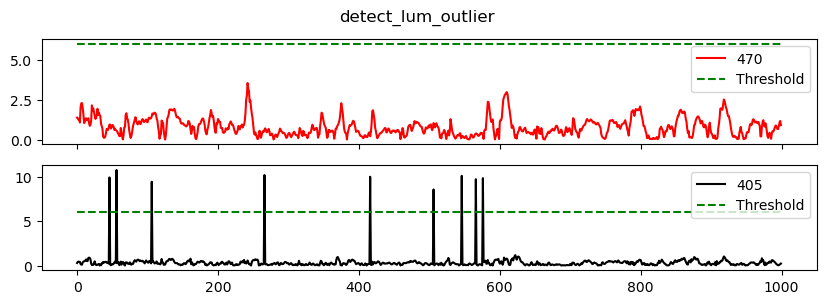

In [8]:
def pre_process_wrap(rawPath, mask=None, n_preview=None):
    """
    A wrapper function to pre-process the raw images.
    Args:
        rawPath: str, path to the raw images
        mask: np.array, brain mask
        n_preview: int or None, number of images to process for preview
    Returns:
        dff: np.array, delta F/F images

    """
    stack, files_470 = images2tiff_two_channel(rawPath, n_preview=n_preview,
        mask=mask,)

    stack_mean = np.mean(stack, axis=(2, 3))
    outlier_index_470, outlier_index_405 = detect_lum_outlier(stack_mean, 
        threshold=6, plot=True)
    
    if len(outlier_index_470) == 0 and len(outlier_index_405) == 0:
        print("No outliers detected, skipping correction step.")
        stack_corrected = stack
    else:
        stack_corrected = correct_lum_outlier(stack, outlier_index_470,
            outlier_index_405, plot=False)

    print("Calculating delta F/F of 470 channel...")
    stack_470_dff = delta_ff_3d(stack_corrected[:, 0, :, :], win=150)
    print("Calculating delta F/F of 405 channel...")
    stack_405_dff = delta_ff_3d(stack_corrected[:, 1, :, :], win=150)

    dff = stack_470_dff - stack_405_dff
    # Scale the dff to range of 16 bit
    dff_min = dff.min()
    dff_max = dff.max()
    dff = 65535 * (dff - dff_min) / (dff_max - dff_min)

    save_path = os.path.join(rawPath, 'dff.tif')
    imwrite(save_path, dff.astype(np.uint16), imagej=True)
    print('The dff tiff file saved to:', save_path)

    # return dff

pre_process_wrap(rawPath, mask=mask)

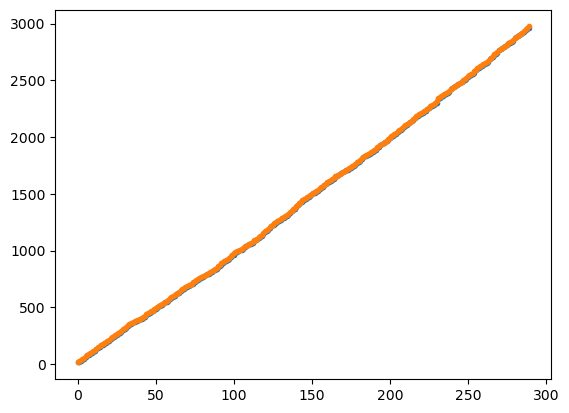

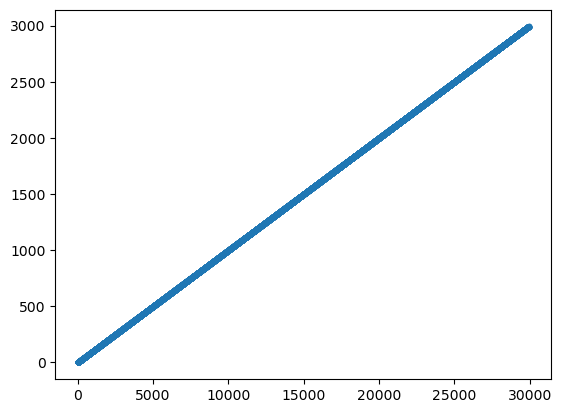

In [159]:
time = np.load(timePath)

In [169]:
wf_path = rawPath+ '/time/widefield_timestamps_blue.npy'
wf_timestamp = np.load(wf_path)

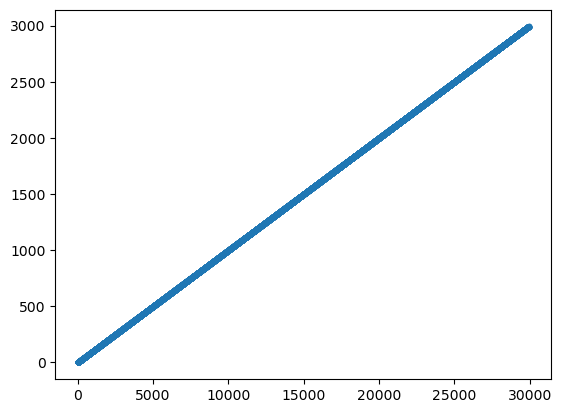

In [175]:
plt.plot(wf_timestamp/1e3,'.')

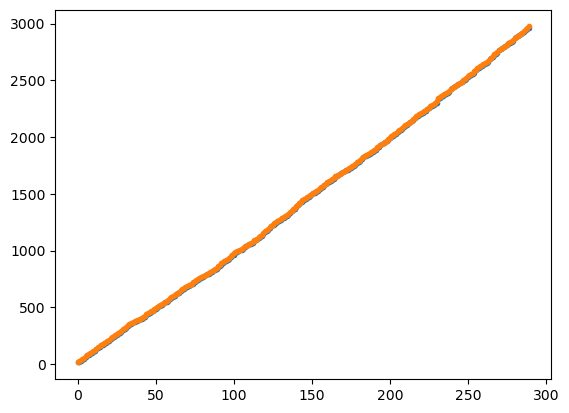

In [173]:
plt.plot(time,'.')

In [124]:
rawPath

'/Volumes/Data_attention/Transfer learning/LinShu/DATA_linshu/000 Widefield/A095/20250905'